In [ ]:
from langgraph.graph import StateGraph, START , END , Literal
from typing import TypedDict


In [2]:
class ModerationState(TypedDict):
    post_content: str
    user_reputation: str

    formatted_post: str
    content_flag: str
    result: str
    


In [3]:
def format_post(state:ModerationState):
    # mirrors 'show_equation' from the original
    formatted = f"User ({state['user_reputation']}) says: {state['post_content']}"
    return {
        'formatted_post': formatted
    }

In [4]:
def analyze_content(state:ModerationState):
    # Mirrors 'calculate_discriminant' from the original
    content = state['post_content'].lower()

    # simple mock logic for content moderation 
    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'

    elif state['user_reputation'] == 'new_user':
        flag = 'review'

    else:
        flag = 'approval'

    return {
        'content_flag' : flag
    }

In [5]:
def approve_post(state:ModerationState):
    result = 'Post published successfully to the timeline.'
    return {
        'result':result
    }

In [6]:
def flag_for_review(state:ModerationState):
    result = 'Post sent to the human moderation queue.'
    return {
        'result': result
    }

In [7]:
def reject_post(state:ModerationState):
    result = 'Post automatically deleted due to policy violation.'
    return {
        'result': result
    }

In [15]:
def check_condition(state:ModerationState) -> Literal["approve_post","flag_for_review","reject_post"]:
    # Mirrors the conditional routing based on the discriminant in the original

    if state['content_flag'] == 'approved':
        return "approved_post"
    elif state['content_flag'] == 'review':
        return 'flag_for_review'
    else:
        return "reject_post"

NameError: name 'Literal' is not defined

In [ ]:
graph = StateGraph(ModerationState)

# add the nodes
graph.add_node('format_post',format_post)
graph.add_node('analyze_content',analyze_content)
graph.add_node('approve_post',approve_post)
graph.add_node('flag_for_review',flag_for_review)
graph.add_node('reject_post',reject_post)



# add edges
graph.add_edge(START, 'format_post')
graph.add_edge('format_post','analyze_content')

# add conditional edges
graph.add_conditioanl_edges('analyze_content')



In [10]:
workflow = graph.compile()

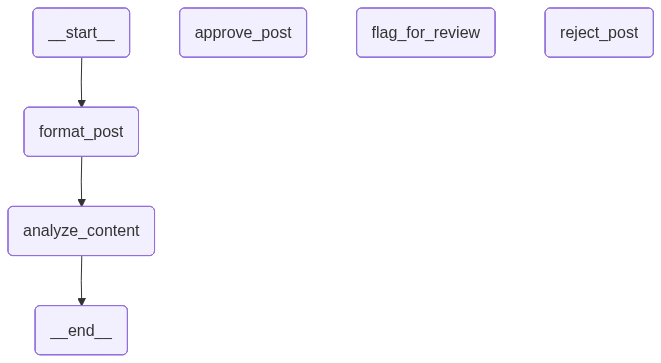

In [11]:
workflow